In [ ]:
# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt

import os
import gzip
import shutil

from pathlib import Path

import tensorflow as tf

import time

In [ ]:
# Essential functions

for gz_file in Path('../global-datasets/tensorflow-number-datasets').glob('*.gz'):
  output_file = gz_file.with_suffix("")
  # print(gz_file, output_file)

  with gzip.open(gz_file, 'rb') as file_in:
    with open(output_file, 'wb') as file_out:
      shutil.copyfileobj(file_in, file_out)
  
  print("Unzip: ", output_file)

def load_image(file_name):
  with open(file_name, 'rb') as f:
    magic_number = int.from_bytes(f.read(4), "big")
    image_count = int.from_bytes(f.read(4), "big")
    image_row = int.from_bytes(f.read(4), "big")
    image_col = int.from_bytes(f.read(4), "big")
    image_data = f.read()

    image = np.frombuffer(
      image_data, dtype=np.uint8
    ).reshape(
      image_count, image_row, image_col
    )
  
  return image

def load_label(file_name):
  with open(file_name, 'rb') as f:
    magic_number = int.from_bytes(f.read(4), 'big')
    count = int.from_bytes(f.read(4), 'big')
    label_data = f.read(count)
    
    label = np.frombuffer(
      label_data, dtype=np.uint8
    )

  return label

In [96]:
# x is data/image
# y is label

num_class = 10

x_train = load_image("../global-datasets/tensorflow-number-datasets/train-images-idx3-ubyte")
y_train = load_label("../global-datasets/tensorflow-number-datasets/train-labels-idx1-ubyte")

x_test = load_image("../global-datasets/tensorflow-number-datasets/t10k-images-idx3-ubyte")
y_test = load_label("../global-datasets/tensorflow-number-datasets/t10k-labels-idx1-ubyte")

# Normalization to make the data value between 0 - 1
x_train = x_train.astype("uint8") / 255
x_test = x_test.astype("uint8") / 255

y_train = tf.keras.utils.to_categorical(y_train, num_class)
y_test = tf.keras.utils.to_categorical(y_test, num_class)

In [83]:
# plt.imshow(x_train[0], cmap="gray")
# plt.title(y_train[0])
# plt.show()

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
# data = x_train[0]
# for i in data:
#   for x in i:
#     if (x > 0.05):
#       print("\x1b[31m%.1f\x1b[0m" %(x), end="") # 31m = Red
#     else:
#       print("%.1f"%(x), end="")
#   print()

# plt.imshow(data, cmap='gray')

In [84]:
# Filter - Hidden Layer

model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

c:\Users\Poorin\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [85]:
# Training

model.compile(optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9112 - loss: 0.3019
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9567 - loss: 0.1466
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9680 - loss: 0.1089
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9724 - loss: 0.0891
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9767 - loss: 0.0741
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9782 - loss: 0.0747


[0.07469134777784348, 0.9782000184059143]

In [86]:
# Predicting
num_class = 10
result_test = model.predict(x_test)

# Convert to one-hot
result_test = tf.keras.utils.to_categorical(result_test, num_class)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


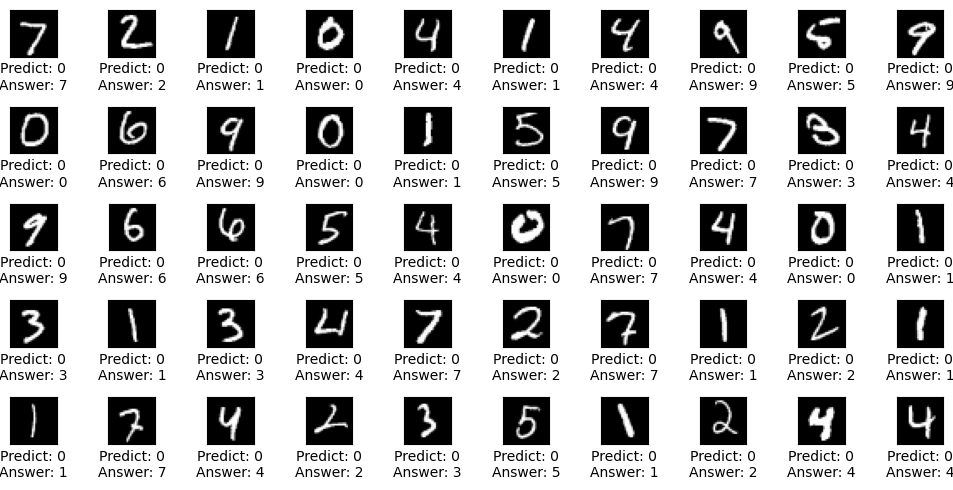

In [87]:
plt.figure(figsize=(10, 5))

for i in range(50):
  plt.subplot(5, 10, i + 1)
  plt.xticks([])
  plt.yticks([])

  plt.xlabel(
    f"Predict: {np.argmax(result_test[i])}\n" +
    f"Answer: {y_test[i]}"
  )
  plt.imshow(x_test[i], cmap="gray")

plt.tight_layout()

In [95]:
print(result_test[0])

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
